In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# Basic Understanding of data 

In [2]:
df = pd.read_csv("customer_support_tickets.csv")  # adjust filename if different

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (20000, 12)

Columns: ['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']

Dtypes:
 Ticket_ID                  str
Customer_Name              str
Customer_Email             str
Ticket_Subject             str
Ticket_Description         str
Issue_Category             str
Priority_Level             str
Ticket_Channel             str
Submission_Date            str
Resolution_Time_Hours    int64
Assigned_Agent             str
Satisfaction_Score       int64
dtype: object

First 3 rows:


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5


### Extract key columns

In [3]:
KEY_COLS = [
    "Ticket_ID",
    "Ticket_Subject",
    "Ticket_Description",
    "Issue_Category",
    "Priority_Level",
    "Ticket_Channel",
    "Resolution_Time_Hours",
    "Satisfaction_Score"
]

df = df[KEY_COLS].copy()
print("Working dataframe shape:", df.shape)
df.head(3)

Working dataframe shape: (20000, 8)


,Ticket_ID,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,Satisfaction_Score
0,TKT-100000,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,5
1,TKT-100001,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,5
2,TKT-100002,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,5


In [4]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)

null_report = pd.DataFrame({
    "null_count": null_counts,
    "null_pct": null_pct
}).sort_values("null_pct", ascending=False)

print(null_report)

                       null_count  null_pct
Ticket_ID                       0       0.0
Ticket_Subject                  0       0.0
Ticket_Description              0       0.0
Issue_Category                  0       0.0
Priority_Level                  0       0.0
Ticket_Channel                  0       0.0
Resolution_Time_Hours           0       0.0
Satisfaction_Score              0       0.0


### Visualisation

In [5]:
priority_order = ["Low", "Medium", "High", "Critical"]
priority_counts = df["Priority_Level"].value_counts().reindex(priority_order)

df["subject_len"] = df["Ticket_Subject"].astype(str).apply(lambda x: len(x.split()))
df["desc_len"] = df["Ticket_Description"].astype(str).apply(lambda x: len(x.split()))

print("Overall text stats:")
print(df[["subject_len", "desc_len"]].describe().round(2))

print("\nAvg description length by priority:")
print(df.groupby("Priority_Level")["desc_len"].mean().round(1).reindex(priority_order))

print("\nAvg resolution time by priority:")
print(df.groupby("Priority_Level")["Resolution_Time_Hours"].mean().round(2).reindex(priority_order))

Overall text stats:
       subject_len  desc_len
count     20000.00  20000.00
mean          4.17     16.93
std           0.38      2.39
min           4.00     10.00
25%           4.00     15.00
50%           4.00     17.00
75%           4.00     19.00
max           5.00     23.00

Avg description length by priority:
Priority_Level
Low         16.6
Medium      16.9
High        17.4
Critical    17.9
Name: desc_len, dtype: float64

Avg resolution time by priority:
Priority_Level
Low         45.17
Medium      44.47
High        24.52
Critical    12.07
Name: Resolution_Time_Hours, dtype: float64


/var/folders/lm/z783vpwd6zjfsgvb0mdpm4b80000gn/T/ipykernel_6187/3288798566.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


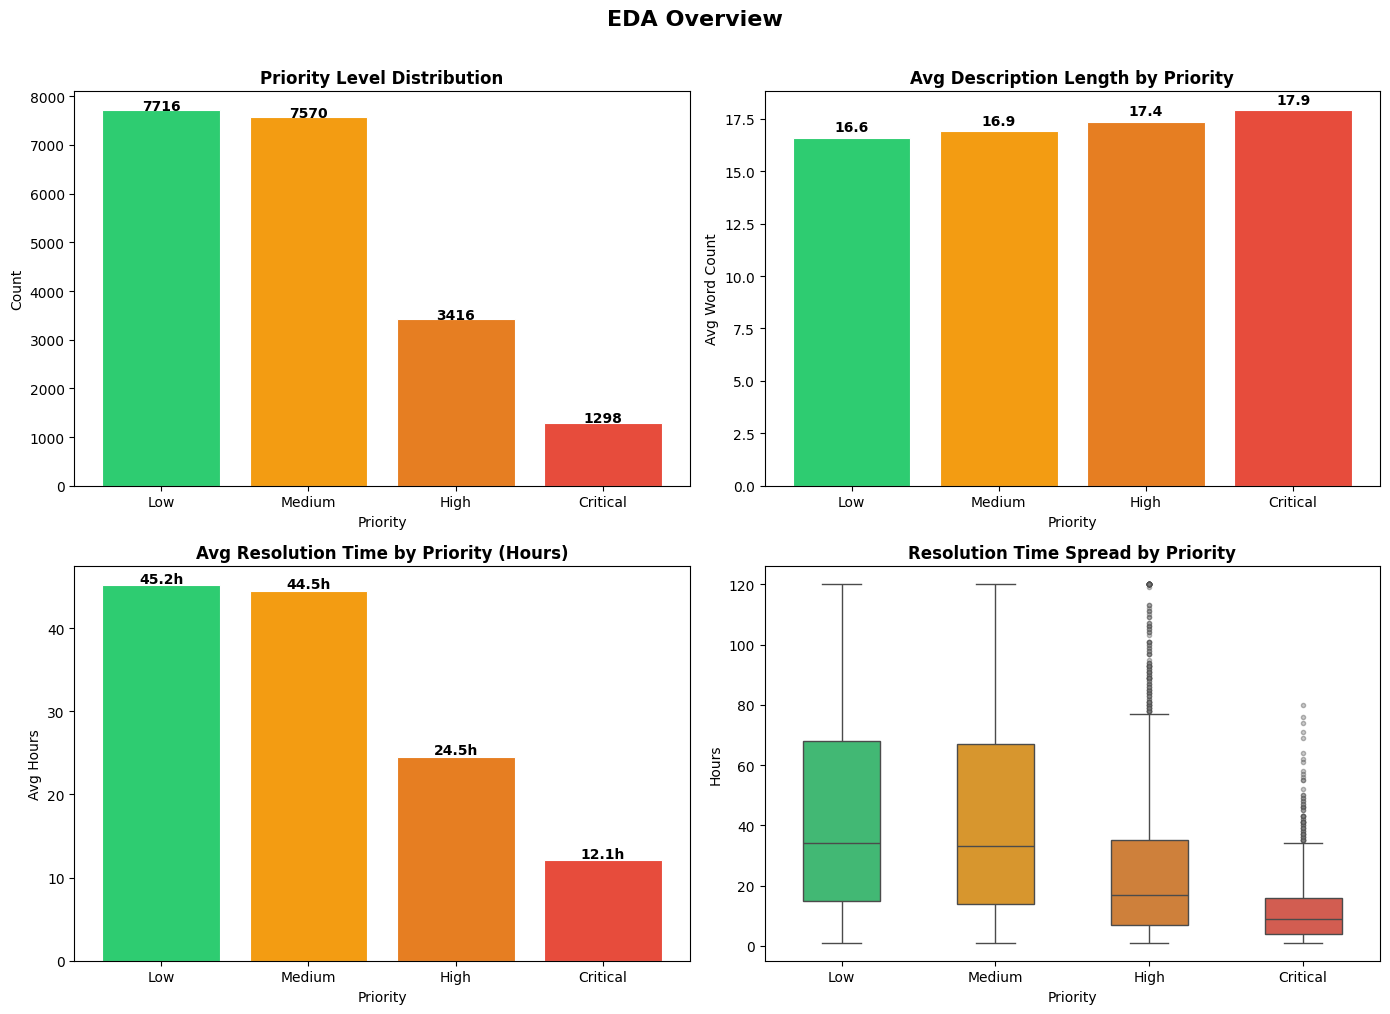

In [6]:
priority_order = ["Low", "Medium", "High", "Critical"]
colors = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA Overview", fontsize=16, fontweight="bold", y=1.01)

# --- Plot 1: Priority Distribution ---
priority_counts = df["Priority_Level"].value_counts().reindex(priority_order)
axes[0, 0].bar(priority_counts.index, priority_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0, 0].set_title("Priority Level Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Priority")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(priority_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha="center", fontsize=10, fontweight="bold")

# --- Plot 2: Avg Description Length by Priority ---
avg_desc = df.groupby("Priority_Level")["desc_len"].mean().reindex(priority_order)
axes[0, 1].bar(avg_desc.index, avg_desc.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0, 1].set_title("Avg Description Length by Priority", fontweight="bold")
axes[0, 1].set_xlabel("Priority")
axes[0, 1].set_ylabel("Avg Word Count")
for i, v in enumerate(avg_desc.values):
    axes[0, 1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold")

# --- Plot 3: Avg Resolution Time by Priority ---
avg_res = df.groupby("Priority_Level")["Resolution_Time_Hours"].mean().reindex(priority_order)
axes[1, 0].bar(avg_res.index, avg_res.values, color=colors, edgecolor="white", linewidth=0.8)
axes[1, 0].set_title("Avg Resolution Time by Priority (Hours)", fontweight="bold")
axes[1, 0].set_xlabel("Priority")
axes[1, 0].set_ylabel("Avg Hours")
for i, v in enumerate(avg_res.values):
    axes[1, 0].text(i, v + 0.3, f"{v:.1f}h", ha="center", fontsize=10, fontweight="bold")

# --- Plot 4: Resolution Time Distribution (Boxplot) ---
priority_palette = dict(zip(priority_order, colors))
sns.boxplot(
    data=df,
    x="Priority_Level",
    y="Resolution_Time_Hours",
    order=priority_order,
    palette=priority_palette,
    ax=axes[1, 1],
    width=0.5,
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=3, alpha=0.4)
)
axes[1, 1].set_title("Resolution Time Spread by Priority", fontweight="bold")
axes[1, 1].set_xlabel("Priority")
axes[1, 1].set_ylabel("Hours")

plt.tight_layout()
plt.show()

/var/folders/lm/z783vpwd6zjfsgvb0mdpm4b80000gn/T/ipykernel_6187/2754577415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


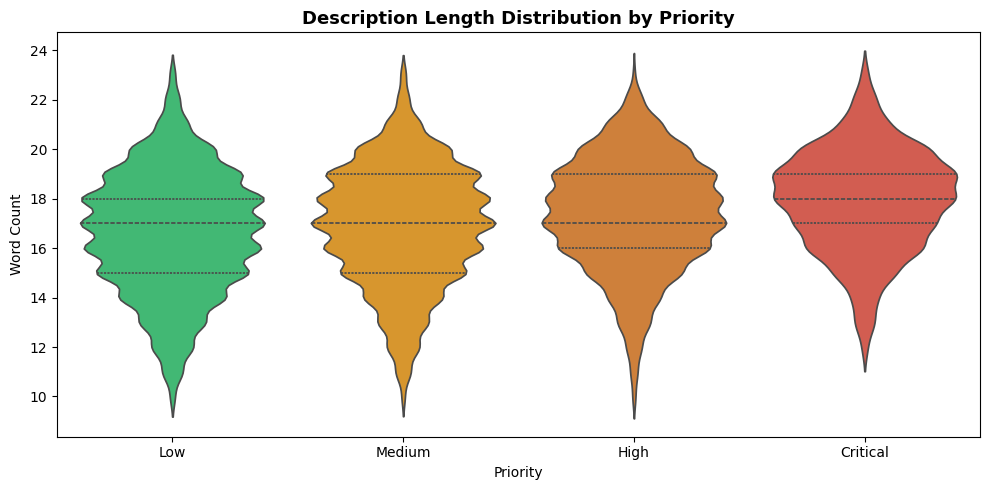

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=df,
    x="Priority_Level",
    y="desc_len",
    order=priority_order,
    palette=priority_palette,
    inner="quartile",
    ax=ax
)
ax.set_title("Description Length Distribution by Priority", fontweight="bold", fontsize=13)
ax.set_xlabel("Priority")
ax.set_ylabel("Word Count")
plt.tight_layout()
plt.show()

### Text Preprocessing

In [8]:
import re
import string

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()                          # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)        # remove URLs
    text = re.sub(r"\S+@\S+", "", text)               # remove emails
    text = re.sub(r"\d+", " ", text)                  # remove standalone numbers
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()          # collapse whitespace
    return text

df["clean_subject"] = df["Ticket_Subject"].apply(clean_text)
df["clean_desc"]    = df["Ticket_Description"].apply(clean_text)

# Combined field — this is what most signals will consume
df["clean_text"] = df["clean_subject"] + " " + df["clean_desc"]

print(df[["Ticket_Subject", "clean_subject", "Ticket_Description", "clean_desc"]].head(3).to_string())

                    Ticket_Subject                  clean_subject                                                                                  Ticket_Description                                                                                       clean_desc
0  Hours of operation - Individual  hours of operation individual                    Hi Support, Where is your headquarters located? Lay soon message show know main.                    hi support where is your headquarters located lay soon message show know main
1          Data not syncing - Card          data not syncing card  Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.  hi support the application crashes every time i open the settings tab speech wall six hour book
2            2FA issues - Question             fa issues question              Hi Support, How do I upgrade to the Enterprise plan? Close stand street wear your her.              hi support how do i upgrade to t

In [9]:
# Spot check a few
for i in range(3):
    print(f"\n--- Ticket {i} ---")
    print("RAW:", df["Ticket_Description"].iloc[i][:200])
    print("CLEAN:", df["clean_text"].iloc[i][:200])


--- Ticket 0 ---
RAW: Hi Support, Where is your headquarters located? Lay soon message show know main.
CLEAN: hours of operation individual hi support where is your headquarters located lay soon message show know main

--- Ticket 1 ---
RAW: Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.
CLEAN: data not syncing card hi support the application crashes every time i open the settings tab speech wall six hour book

--- Ticket 2 ---
RAW: Hi Support, How do I upgrade to the Enterprise plan? Close stand street wear your her.
CLEAN: fa issues question hi support how do i upgrade to the enterprise plan close stand street wear your her


In [10]:
# Check for any empty clean_text after preprocessing
empty_mask = df["clean_text"].str.strip() == ""
print(f"Empty clean_text rows: {empty_mask.sum()}")

# Drop them if any
df = df[~empty_mask].reset_index(drop=True)
print(f"Remaining rows: {len(df)}")

Empty clean_text rows: 0
Remaining rows: 20000


In [11]:
df["clean_text_len"] = df["clean_text"].apply(lambda x: len(x.split()))

print(df["clean_text_len"].describe().round(2))
print("\nAvg cleaned text length by priority:")
print(df.groupby("Priority_Level")["clean_text_len"].mean().round(1).reindex(priority_order))

count    20000.00
mean        19.92
std          2.38
min         13.00
25%         18.00
50%         20.00
75%         22.00
max         27.00
Name: clean_text_len, dtype: float64

Avg cleaned text length by priority:
Priority_Level
Low         19.6
Medium      19.9
High        20.3
Critical    21.0
Name: clean_text_len, dtype: float64


In [12]:
df.head()

,Ticket_ID,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,Satisfaction_Score,subject_len,desc_len,clean_subject,clean_desc,clean_text,clean_text_len
0,TKT-100000,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,5,5,13,hours of operation individual,hi support where is your headquarters located ...,hours of operation individual hi support where...,17
1,TKT-100001,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,5,5,17,data not syncing card,hi support the application crashes every time ...,data not syncing card hi support the applicati...,21
2,TKT-100002,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,5,4,16,fa issues question,hi support how do i upgrade to the enterprise ...,fa issues question hi support how do i upgrade...,19
3,TKT-100003,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,41,5,4,17,login failed let,hi support the dashboard is not loading any da...,login failed let hi support the dashboard is n...,20
4,TKT-100004,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,40,5,4,18,refund status attention,hi support i have been trying to update my pay...,refund status attention hi support i have been...,21


### Encode categorical features

In [13]:
from sklearn.preprocessing import LabelEncoder

print("Unique Priority_Level values:", df["Priority_Level"].unique())
print("\nUnique Ticket_Channel values:", df["Ticket_Channel"].unique())
print("\nUnique Issue_Category values:", df["Issue_Category"].unique())

Unique Priority_Level values: <ArrowStringArray>
['High', 'Low', 'Medium', 'Critical']
Length: 4, dtype: str

Unique Ticket_Channel values: <ArrowStringArray>
['Web Form', 'Chat', 'Email']
Length: 3, dtype: str

Unique Issue_Category values: <ArrowStringArray>
['General Inquiry', 'Technical', 'Account', 'Billing', 'Fraud']
Length: 5, dtype: str


In [14]:
priority_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
df["priority_encoded"] = df["Priority_Level"].str.strip().map(priority_map).astype(int)

Split train and test

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["priority_encoded"])

print("Train size:", len(train_df))
print("Test size: ", len(test_df))

Train size: 16000
Test size:  4000


In [16]:
# create encoder
le_channel = LabelEncoder()
train_df["channel_encoded"] = le_channel.fit_transform(train_df["Ticket_Channel"].astype(str))
test_df["channel_encoded"] = le_channel.transform(test_df["Ticket_Channel"].astype(str))

# display mapping
print("Channel mapping:")
print(dict(zip(le_channel.classes_,le_channel.transform(le_channel.classes_))))

Channel mapping:
{'Chat': np.int64(0), 'Email': np.int64(1), 'Web Form': np.int64(2)}


In [17]:
# create encoder
le_category = LabelEncoder()
train_df["category_encoded"] = le_category.fit_transform(train_df["Issue_Category"].astype(str))
test_df["category_encoded"] = le_category.transform(test_df["Issue_Category"].astype(str))

# display mapping
print("\nCategory mapping:")
print(dict(zip(le_category.classes_,le_category.transform(le_category.classes_))))


Category mapping:
{'Account': np.int64(0), 'Billing': np.int64(1), 'Fraud': np.int64(2), 'General Inquiry': np.int64(3), 'Technical': np.int64(4)}


### Normalization

In [18]:
print(df[["Resolution_Time_Hours","Satisfaction_Score"]].describe().round(2))
print("\nNulls in resolution time:", df["Resolution_Time_Hours"].isnull().sum())

       Resolution_Time_Hours  Satisfaction_Score
count               20000.00            20000.00
mean                   39.23                3.72
std                    35.22                1.29
min                     1.00                1.00
25%                    11.00                3.00
50%                    27.00                4.00
75%                    58.00                5.00
max                   120.00                5.00

Nulls in resolution time: 0


In [19]:
scaler = MinMaxScaler()
train_df = train_df.copy()
test_df = test_df.copy()

train_df["resolution_time_norm"] = scaler.fit_transform(train_df[["Resolution_Time_Hours"]])
test_df["resolution_time_norm"]  = scaler.transform(test_df[["Resolution_Time_Hours"]]) 

print("\nTrain resolution_time_norm stats:")
print(train_df["resolution_time_norm"].describe().round(3))

print("\nTest resolution_time_norm stats:")
print(test_df["resolution_time_norm"].describe().round(3))


Train resolution_time_norm stats:
count    16000.000
mean         0.322
std          0.296
min          0.000
25%          0.084
50%          0.218
75%          0.479
max          1.000
Name: resolution_time_norm, dtype: float64

Test resolution_time_norm stats:
count    4000.000
mean        0.320
std         0.298
min         0.000
25%         0.076
50%         0.227
75%         0.473
max         1.000
Name: resolution_time_norm, dtype: float64


# Embedding-Based Clustering

In [24]:
print("Loading sentence transformer model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding train embeddings...")
train_embeddings = model.encode(
    train_df["clean_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Encoding test embeddings...")
test_embeddings = model.encode(
    test_df["clean_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Train embeddings shape:", train_embeddings.shape)
print("Test embeddings shape: ", test_embeddings.shape)

Loading sentence transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding train embeddings...


Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Encoding test embeddings...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Train embeddings shape: (16000, 384)
Test embeddings shape:  (4000, 384)


k=2 → silhouette score: 0.0809
k=3 → silhouette score: 0.0919
k=4 → silhouette score: 0.1092
k=5 → silhouette score: 0.1111
k=6 → silhouette score: 0.1048
k=7 → silhouette score: 0.0925
k=8 → silhouette score: 0.1102

Best k: 5


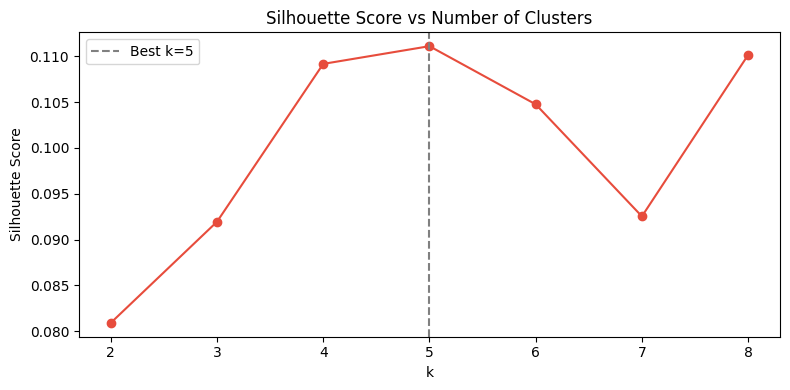

In [25]:
silhouette_scores = {}
for k in range(2, 9):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(train_embeddings)
    score = silhouette_score(train_embeddings, labels, sample_size=2000, random_state=42)
    silhouette_scores[k] = score
    print(f"k={k} → silhouette score: {score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k: {best_k}")

plt.figure(figsize=(8, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="#e74c3c")
plt.axvline(x=best_k, linestyle="--", color="gray", label=f"Best k={best_k}")
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_df["cluster"] = kmeans.fit_predict(train_embeddings)
test_df["cluster"]  = kmeans.predict(test_embeddings)

print("Train cluster distribution:")
print(train_df["cluster"].value_counts().sort_index())

print("\nTest cluster distribution:")
print(test_df["cluster"].value_counts().sort_index())

Train cluster distribution:
cluster
0    4175
1    4525
2    2212
3    3272
4    1816
Name: count, dtype: int64

Test cluster distribution:
cluster
0    1048
1    1099
2     538
3     859
4     456
Name: count, dtype: int64


In [27]:
cluster_avg_resolution = train_df.groupby("cluster")["Resolution_Time_Hours"].mean()
median_resolution      = cluster_avg_resolution.median()

binary_severity_map = {
    cluster: (1 if avg_res >= median_resolution else 0)
    for cluster, avg_res in cluster_avg_resolution.items()
}

print("\nCluster → Binary Severity (0=Low-Medium, 1=High-Critical):")
print(binary_severity_map)

train_df["inferred_severity_binary"] = train_df["cluster"].map(binary_severity_map)
test_df["inferred_severity_binary"]  = test_df["cluster"].map(binary_severity_map)

print("\nTrain inferred severity distribution:")
print(train_df["inferred_severity_binary"].value_counts())


Cluster → Binary Severity (0=Low-Medium, 1=High-Critical):
{0: 1, 1: 1, 2: 0, 3: 1, 4: 0}

Train inferred severity distribution:
inferred_severity_binary
1    11972
0     4028
Name: count, dtype: int64


In [28]:
binary_priority_map = {"Low": 0, "Medium": 0, "High": 1, "Critical": 1}

train_df["priority_binary"] = train_df["Priority_Level"].map(binary_priority_map)
test_df["priority_binary"]  = test_df["Priority_Level"].map(binary_priority_map)

print("\nTrain assigned binary priority distribution:")
print(train_df["priority_binary"].value_counts())


Train assigned binary priority distribution:
priority_binary
0    12229
1     3771
Name: count, dtype: int64


In [31]:
print("\nFitting UMAP on train...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
train_2d = reducer.fit_transform(train_embeddings)

print("Transforming test with fitted UMAP...")
test_2d = reducer.transform(test_embeddings)

train_df["umap_x"] = train_2d[:, 0]
train_df["umap_y"] = train_2d[:, 1]
test_df["umap_x"]  = test_2d[:, 0]
test_df["umap_y"]  = test_2d[:, 1]


Fitting UMAP on train...


/Users/aditibharadwaj/Documents/MARS/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Transforming test with fitted UMAP...


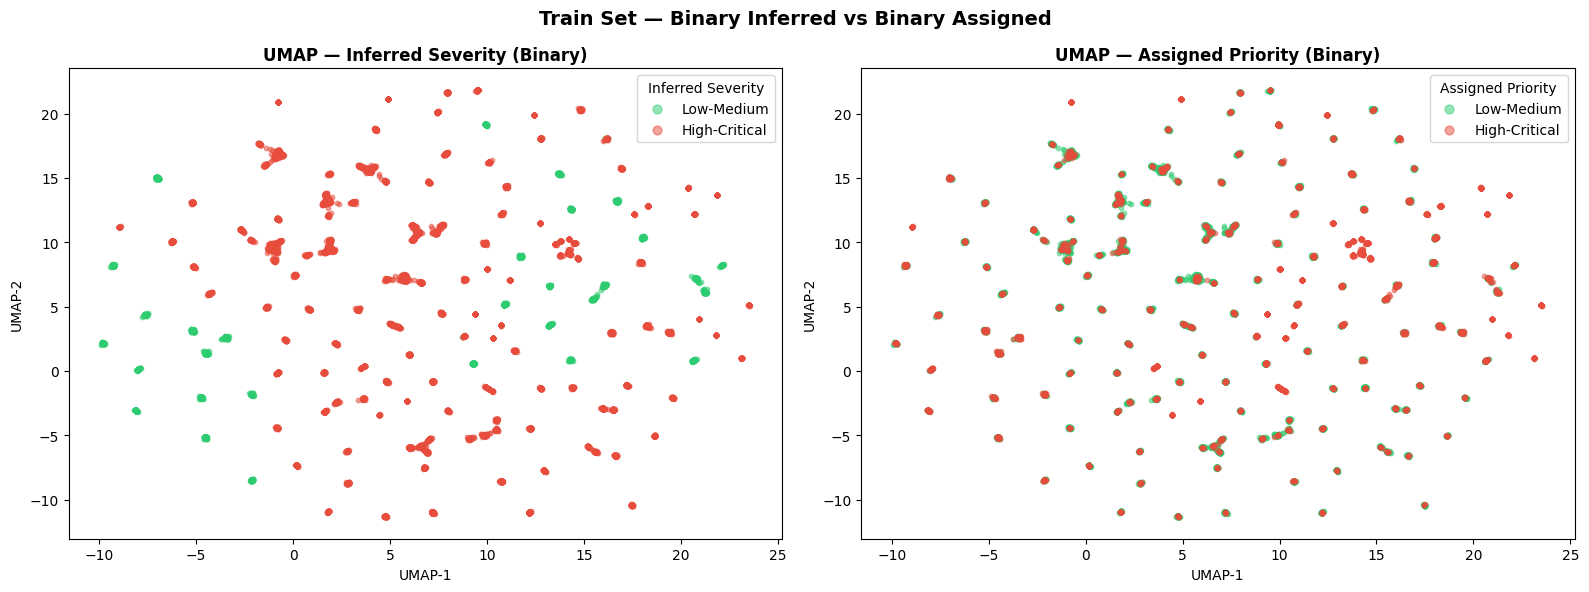

In [32]:
binary_colors = ["#2ecc71", "#e74c3c"]
binary_labels = {0: "Low-Medium", 1: "High-Critical"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for sev in [0, 1]:
    mask = train_df["inferred_severity_binary"] == sev
    axes[0].scatter(
        train_df.loc[mask, "umap_x"],
        train_df.loc[mask, "umap_y"],
        c=binary_colors[sev],
        label=binary_labels[sev],
        alpha=0.5, s=10
    )
axes[0].set_title("UMAP — Inferred Severity (Binary)", fontweight="bold")
axes[0].legend(title="Inferred Severity", markerscale=2)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

for sev in [0, 1]:
    mask = train_df["priority_binary"] == sev
    axes[1].scatter(
        train_df.loc[mask, "umap_x"],
        train_df.loc[mask, "umap_y"],
        c=binary_colors[sev],
        label=binary_labels[sev],
        alpha=0.5, s=10
    )
axes[1].set_title("UMAP — Assigned Priority (Binary)", fontweight="bold")
axes[1].legend(title="Assigned Priority", markerscale=2)
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.suptitle("Train Set — Binary Inferred vs Binary Assigned", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Generate Mismatch Label

In [33]:
# ── GENERATE MISMATCH LABEL ───────────────────────────────────────────────────
# mismatch = 1 where inferred severity disagrees with assigned priority
# mismatch = 0 where they agree

train_df["mismatch_label"] = (
    train_df["inferred_severity_binary"] != train_df["priority_binary"]
).astype(int)

test_df["mismatch_label"] = (
    test_df["inferred_severity_binary"] != test_df["priority_binary"]
).astype(int)

print("=== TRAIN Mismatch Distribution ===")
train_counts = train_df["mismatch_label"].value_counts()
print(f"Consistent  (0): {train_counts[0]} ({100*train_counts[0]/len(train_df):.1f}%)")
print(f"Mismatch    (1): {train_counts[1]} ({100*train_counts[1]/len(train_df):.1f}%)")

print("\n=== TEST Mismatch Distribution ===")
test_counts = test_df["mismatch_label"].value_counts()
print(f"Consistent  (0): {test_counts[0]} ({100*test_counts[0]/len(test_df):.1f}%)")
print(f"Mismatch    (1): {test_counts[1]} ({100*test_counts[1]/len(test_df):.1f}%)")

=== TRAIN Mismatch Distribution ===
Consistent  (0): 4633 (29.0%)
Mismatch    (1): 11367 (71.0%)

=== TEST Mismatch Distribution ===
Consistent  (0): 1145 (28.6%)
Mismatch    (1): 2855 (71.4%)


In [34]:
# Also tag mismatch TYPE — Hidden Crisis vs False Alarm
def mismatch_type(row):
    if row["mismatch_label"] == 0:
        return "Consistent"
    elif row["inferred_severity_binary"] == 1 and row["priority_binary"] == 0:
        return "Hidden Crisis"   # ticket is actually severe but labeled Low/Medium
    else:
        return "False Alarm"     # ticket is not severe but labeled High/Critical

train_df["mismatch_type"] = train_df.apply(mismatch_type, axis=1)
test_df["mismatch_type"]  = test_df.apply(mismatch_type, axis=1)

print("\n=== TRAIN Mismatch Type Breakdown ===")
print(train_df["mismatch_type"].value_counts())

print("\n=== TEST Mismatch Type Breakdown ===")
print(test_df["mismatch_type"].value_counts())


=== TRAIN Mismatch Type Breakdown ===
mismatch_type
Hidden Crisis    9784
Consistent       4633
False Alarm      1583
Name: count, dtype: int64

=== TEST Mismatch Type Breakdown ===
mismatch_type
Hidden Crisis    2459
Consistent       1145
False Alarm       396
Name: count, dtype: int64


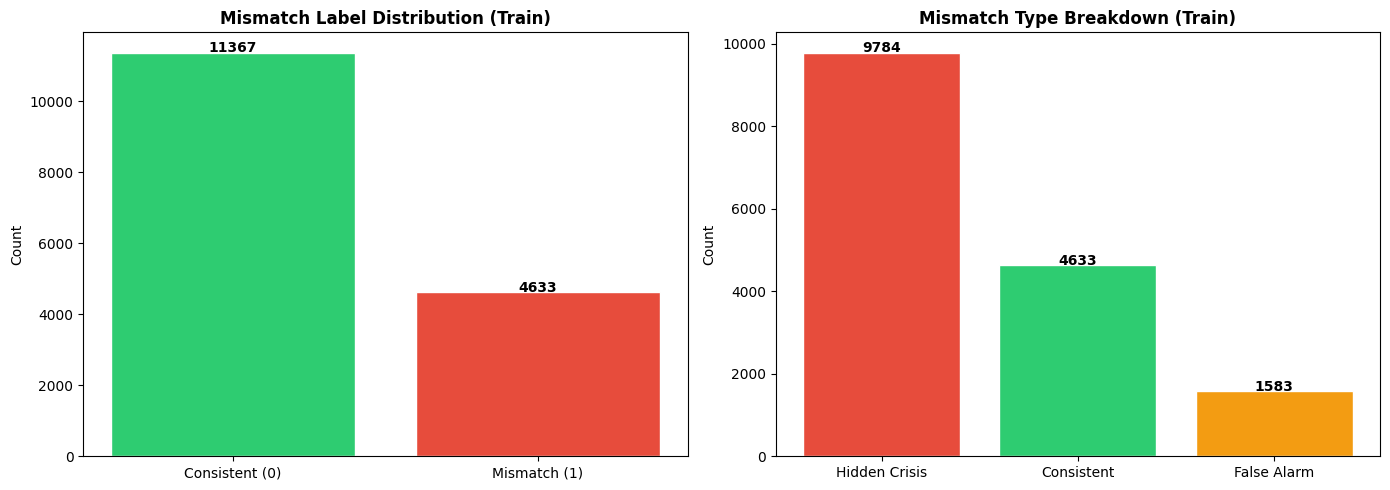

In [35]:
# Visualize mismatch distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary mismatch
mismatch_counts = train_df["mismatch_label"].value_counts()
axes[0].bar(["Consistent (0)", "Mismatch (1)"],
            mismatch_counts.values,
            color=["#2ecc71", "#e74c3c"],
            edgecolor="white")
axes[0].set_title("Mismatch Label Distribution (Train)", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(mismatch_counts.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

# Mismatch type breakdown
type_counts = train_df["mismatch_type"].value_counts()
colors_type = {"Consistent": "#2ecc71", "Hidden Crisis": "#e74c3c", "False Alarm": "#f39c12"}
axes[1].bar(type_counts.index,
            type_counts.values,
            color=[colors_type[t] for t in type_counts.index],
            edgecolor="white")
axes[1].set_title("Mismatch Type Breakdown (Train)", fontweight="bold")
axes[1].set_ylabel("Count")
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 2, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()